✅ All imports successful


/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)


Downloaded 500 days of data
Downloaded 500 days of data
✅ Downloaded 499 days
Current price: $187.67
Historical mu: 69.76%
Historical sigma: 51.01%

Fitting GARCH...
GARCH 6-month avg vol: 47.02%
Historical constant vol: 51.01%

MODEL 1: Basic Monte Carlo (Constant Volatility)
Running 5,000 simulations...


/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:83: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data['Close'].iloc[-1])
/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu = float(daily_mean * 252)
/workspaces/myfolder/sas-curiosity-cup-2025/src/data/fetch.py:59: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma = float(daily_std * np.sqrt(252))


Expected price: $309.74
95% VaR: $137.19
Prob of loss: 16.9%

MODEL 2: Jump Diffusion (Constant Volatility)
Running 5,000 simulations...
Simulation 0/5000
Simulation 1000/5000
Simulation 2000/5000
Simulation 3000/5000
Simulation 4000/5000
Expected price: $286.29
95% VaR: $122.19
Prob of loss: 24.0%
Prob of 20%+ loss: 11.6%

MODEL 3: Jump Diffusion + GARCH (Dynamic Volatility)
Running 5,000 simulations...
Simulation 0/5000
Simulation 1000/5000
Simulation 2000/5000
Simulation 3000/5000
Simulation 4000/5000
Expected price: $282.22
95% VaR: $128.67
Prob of loss: 22.3%
Prob of 20%+ loss: 9.7%

MODEL COMPARISON SUMMARY
         Model        Volatility Used Expected Price 95% VaR Prob Loss Prob 20%+ Loss
      Basic MC       51.0% (constant)        $309.74 $137.19     16.9%            N/A
Jump Diffusion       51.0% (constant)        $286.29 $122.19     24.0%          11.6%
    JD + GARCH 47.0% (GARCH forecast)        $282.22 $128.67     22.3%           9.7%


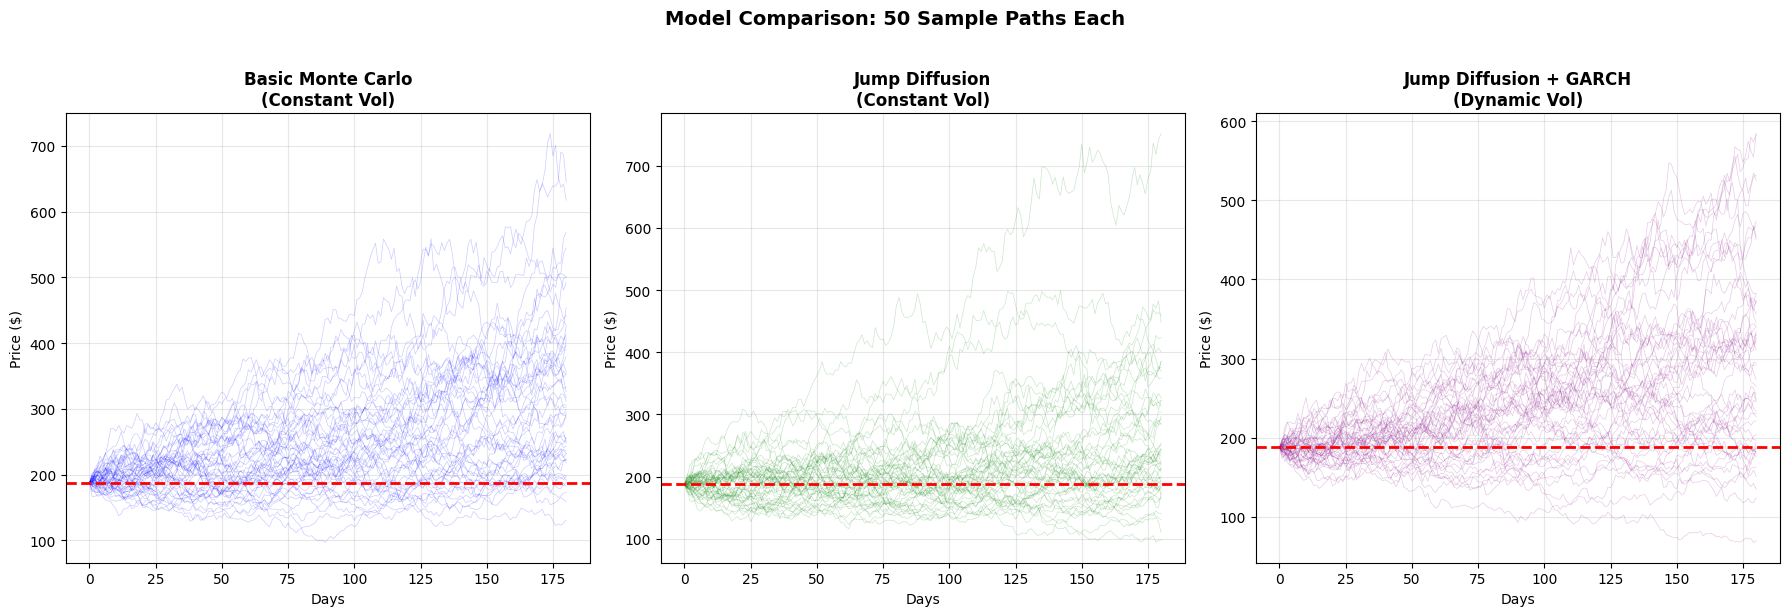

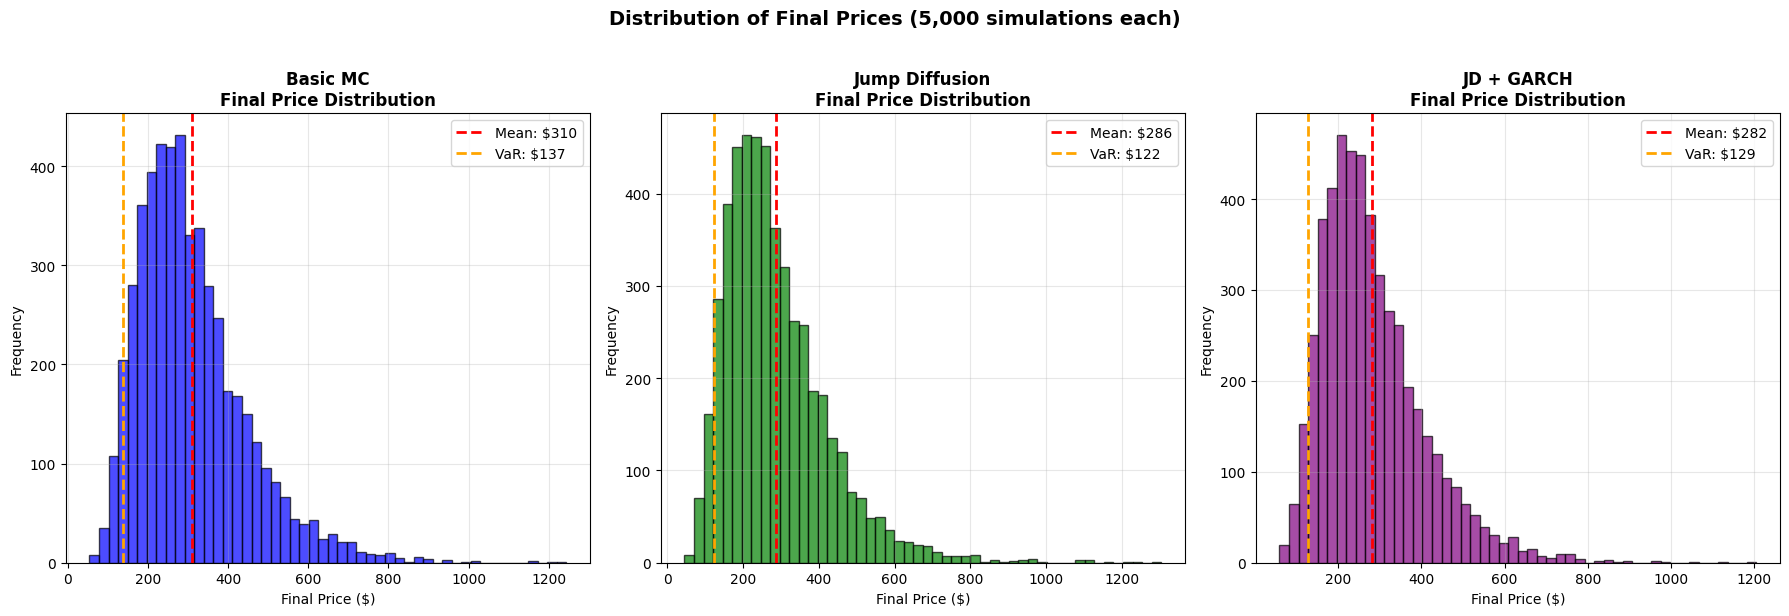


✅ Model comparison complete!


In [1]:
# Cell 1: Setup
import sys
import os
import subprocess

# Install arch
subprocess.run([sys.executable, "-m", "pip", "install", "arch", "-q"])

# Setup paths
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(repo_root)

# Import everything
from src.models.garch import GARCHVolatilityForecaster
from src.models.monte_carlo import MonteCarloSimulator
from src.models.monte_carlo_advanced import JumpDiffusionMC
from src.data.fetch import download_stock_data, calculate_returns, get_stock_parameters
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("✅ All imports successful")

# Cell 2: Get NVDA data
end = datetime.now().strftime('%Y-%m-%d')
start = (datetime.now() - timedelta(days=730)).strftime('%Y-%m-%d')

print(f"Downloading NVDA from {start} to {end}...")
data = download_stock_data('NVDA', start, end)
returns = calculate_returns(data)
params = get_stock_parameters('NVDA', start, end)

print(f"✅ Downloaded {len(returns)} days")
print(f"Current price: ${params['S0']:.2f}")
print(f"Historical mu: {params['mu']*100:.2f}%")
print(f"Historical sigma: {params['sigma']*100:.2f}%")

# Cell 3: Fit GARCH for dynamic volatility
print("\nFitting GARCH...")
garch = GARCHVolatilityForecaster(returns)
garch.fit()
garch_forecast = garch.forecast_volatility(horizon=180)
avg_garch_vol = garch_forecast.mean()

print(f"GARCH 6-month avg vol: {avg_garch_vol*100:.2f}%")
print(f"Historical constant vol: {params['sigma']*100:.2f}%")

# Cell 4: Run Model 1 - Basic Monte Carlo
print("\n" + "="*70)
print("MODEL 1: Basic Monte Carlo (Constant Volatility)")
print("="*70)

basic_mc = MonteCarloSimulator(
    S0=params['S0'],
    mu=params['mu'],
    sigma=params['sigma'],  # Historical constant vol
    days=180
)

print("Running 5,000 simulations...")
basic_paths = basic_mc.run_simulation(n_simulations=5000)
basic_final = basic_paths[:, -1]
basic_stats = basic_mc.get_statistics(basic_final)

print(f"Expected price: ${basic_stats['mean']:.2f}")
print(f"95% VaR: ${basic_stats['var_95']:.2f}")
print(f"Prob of loss: {basic_stats['prob_loss']*100:.1f}%")

# Cell 5: Run Model 2 - Jump Diffusion (Constant Vol)
print("\n" + "="*70)
print("MODEL 2: Jump Diffusion (Constant Volatility)")
print("="*70)

jd_constant = JumpDiffusionMC(
    S0=params['S0'],
    mu=params['mu'],
    sigma=params['sigma'],  # Still constant vol
    days=180
)

print("Running 5,000 simulations...")
jd_constant_paths = jd_constant.run_simulation(n_simulations=5000)
jd_constant_final = jd_constant_paths[:, -1]
jd_constant_stats = jd_constant.calculate_statistics(jd_constant_final)

print(f"Expected price: ${jd_constant_stats['mean']:.2f}")
print(f"95% VaR: ${jd_constant_stats['var_95']:.2f}")
print(f"Prob of loss: {jd_constant_stats['prob_loss']*100:.1f}%")
print(f"Prob of 20%+ loss: {jd_constant_stats['prob_large_loss']*100:.1f}%")

# Cell 6: Run Model 3 - Jump Diffusion + GARCH
print("\n" + "="*70)
print("MODEL 3: Jump Diffusion + GARCH (Dynamic Volatility)")
print("="*70)

jd_garch = JumpDiffusionMC(
    S0=params['S0'],
    mu=params['mu'],
    sigma=avg_garch_vol,  # GARCH dynamic vol
    days=180
)

print("Running 5,000 simulations...")
jd_garch_paths = jd_garch.run_simulation(n_simulations=5000)
jd_garch_final = jd_garch_paths[:, -1]
jd_garch_stats = jd_garch.calculate_statistics(jd_garch_final)

print(f"Expected price: ${jd_garch_stats['mean']:.2f}")
print(f"95% VaR: ${jd_garch_stats['var_95']:.2f}")
print(f"Prob of loss: {jd_garch_stats['prob_loss']*100:.1f}%")
print(f"Prob of 20%+ loss: {jd_garch_stats['prob_large_loss']*100:.1f}%")

# Cell 7: Create Comparison Table
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

comparison = pd.DataFrame({
    'Model': [
        'Basic MC',
        'Jump Diffusion',
        'JD + GARCH'
    ],
    'Volatility Used': [
        f"{params['sigma']*100:.1f}% (constant)",
        f"{params['sigma']*100:.1f}% (constant)",
        f"{avg_garch_vol*100:.1f}% (GARCH forecast)"
    ],
    'Expected Price': [
        f"${basic_stats['mean']:.2f}",
        f"${jd_constant_stats['mean']:.2f}",
        f"${jd_garch_stats['mean']:.2f}"
    ],
    '95% VaR': [
        f"${basic_stats['var_95']:.2f}",
        f"${jd_constant_stats['var_95']:.2f}",
        f"${jd_garch_stats['var_95']:.2f}"
    ],
    'Prob Loss': [
        f"{basic_stats['prob_loss']*100:.1f}%",
        f"{jd_constant_stats['prob_loss']*100:.1f}%",
        f"{jd_garch_stats['prob_loss']*100:.1f}%"
    ],
    'Prob 20%+ Loss': [
        'N/A',
        f"{jd_constant_stats['prob_large_loss']*100:.1f}%",
        f"{jd_garch_stats['prob_large_loss']*100:.1f}%"
    ]
})

print(comparison.to_string(index=False))

# Cell 8: Visualization - Side-by-side sample paths
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Basic MC
for i in range(50):
    axes[0].plot(basic_paths[i], alpha=0.2, color='blue', linewidth=0.5)
axes[0].axhline(y=params['S0'], color='red', linestyle='--', linewidth=2)
axes[0].set_title('Basic Monte Carlo\n(Constant Vol)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Jump Diffusion (constant)
for i in range(50):
    axes[1].plot(jd_constant_paths[i], alpha=0.2, color='green', linewidth=0.5)
axes[1].axhline(y=params['S0'], color='red', linestyle='--', linewidth=2)
axes[1].set_title('Jump Diffusion\n(Constant Vol)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Price ($)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Jump Diffusion + GARCH
for i in range(50):
    axes[2].plot(jd_garch_paths[i], alpha=0.2, color='purple', linewidth=0.5)
axes[2].axhline(y=params['S0'], color='red', linestyle='--', linewidth=2)
axes[2].set_title('Jump Diffusion + GARCH\n(Dynamic Vol)', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Days')
axes[2].set_ylabel('Price ($)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Model Comparison: 50 Sample Paths Each', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cell 9: Visualization - Distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Distribution 1: Basic MC
axes[0].hist(basic_final, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(basic_stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: ${basic_stats['mean']:.0f}")
axes[0].axvline(basic_stats['var_95'], color='orange', linestyle='--', linewidth=2, label=f"VaR: ${basic_stats['var_95']:.0f}")
axes[0].set_title('Basic MC\nFinal Price Distribution', fontweight='bold')
axes[0].set_xlabel('Final Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution 2: Jump Diffusion (constant)
axes[1].hist(jd_constant_final, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(jd_constant_stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: ${jd_constant_stats['mean']:.0f}")
axes[1].axvline(jd_constant_stats['var_95'], color='orange', linestyle='--', linewidth=2, label=f"VaR: ${jd_constant_stats['var_95']:.0f}")
axes[1].set_title('Jump Diffusion\nFinal Price Distribution', fontweight='bold')
axes[1].set_xlabel('Final Price ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Distribution 3: Jump Diffusion + GARCH
axes[2].hist(jd_garch_final, bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[2].axvline(jd_garch_stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: ${jd_garch_stats['mean']:.0f}")
axes[2].axvline(jd_garch_stats['var_95'], color='orange', linestyle='--', linewidth=2, label=f"VaR: ${jd_garch_stats['var_95']:.0f}")
axes[2].set_title('JD + GARCH\nFinal Price Distribution', fontweight='bold')
axes[2].set_xlabel('Final Price ($)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Distribution of Final Prices (5,000 simulations each)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ Model comparison complete!")